# Inferencia estadística vs Aprendizaje de máquinas

### Parte 1: Ajuste de recta 

(Adaptado de  Viviana Acquaviva (2023))

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
#parámetros para generar figuras de alta calidad
font = {'size'   : 12}
plt.rc('font', **font)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rcParams.update({'figure.autolayout': False})
plt.rcParams['figure.dpi'] = 300

Generaremos datos que sigan una relación lineal (con ruido) y usaremos una grilla para encontrar el mejor ajuste, sin y con considerar incertezas

In [7]:
np.random.seed(16) #semilla fija para reproducibilidad

x = np.arange(10) 

y = 2*x + 5 + np.random.randn(10) #generamos datos con scatter gausiano

Podemos considerar que los datos corresponden al movimiento de un auto con rapidez constante, donde $x$ es tiempo (en segundos) e $y$ es distancia (en metros)

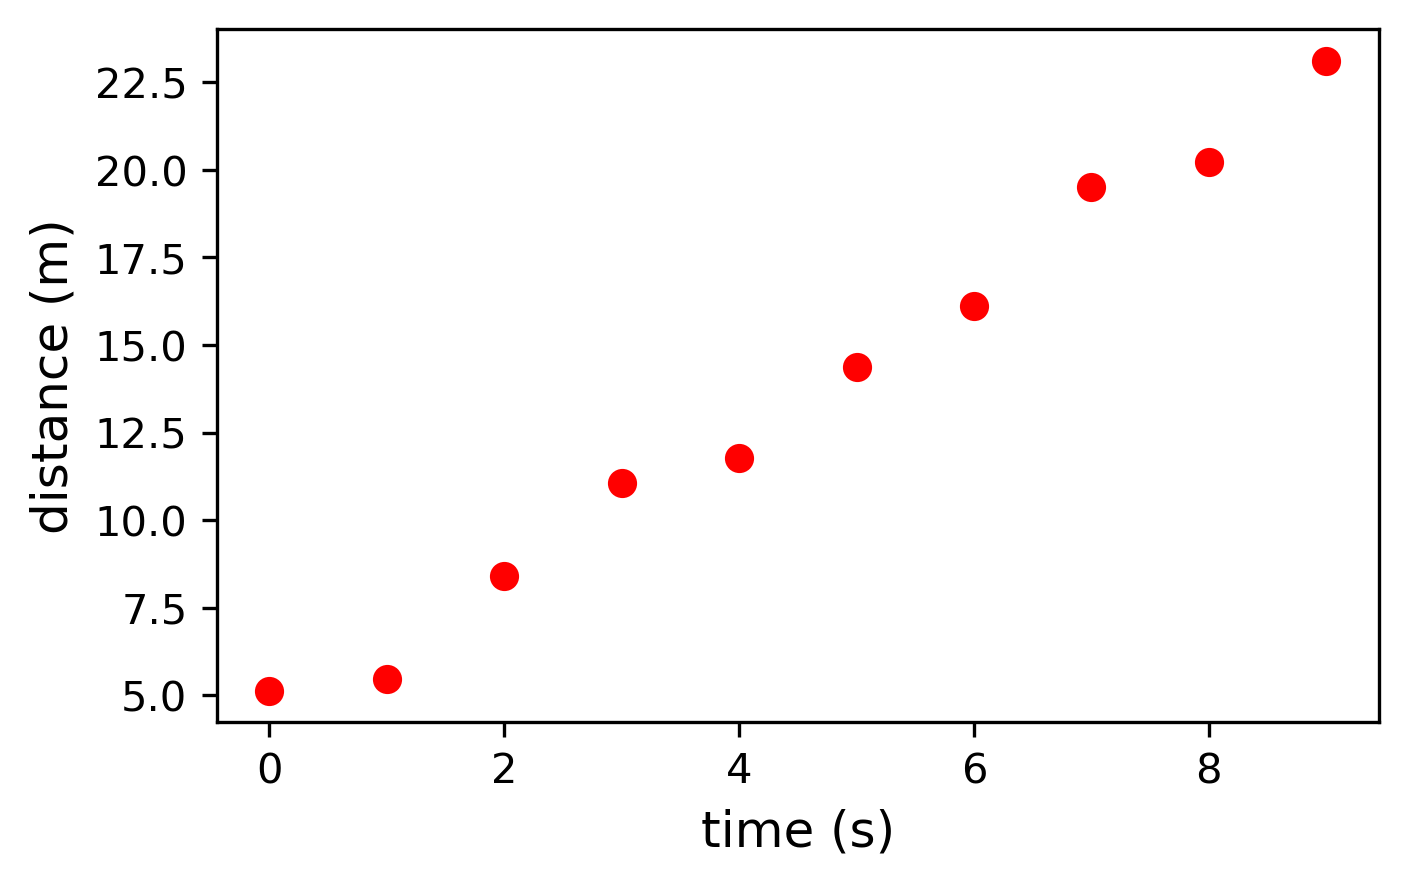

In [8]:
plt.figure(figsize=(5,3)) 
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [9]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [10]:
y = np.round(y,1) #redondeamos los datos

In [11]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

Suponga que a partir de esos datos debe ser capaz de decir la distancia a la que estará el auto cuando $t=12$ s. ¿Cómo podemos resolver el problema?

### Inferencia

Ya sabemos que la relación entre distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Este modelo tienen dos parámetros: $d_0$ u $v$. Necesitamos encontrar estos parámetros para poder usar el modelo y determinar $d(t=12 s)$.


¿Cómo haría esto?




Explique con palabras: **Con los datos presentes se puede generar una curva de la forma $d(t)=d_0 + vt$ que modele y entregue los parámetros $d_0$(intercepto) y $v$(pendiente). Estos nos permitirán determinar el valor estimado de $d$ en $t=12$, considerando que los parámetros obtenidos son los que mejor modelan los datos dispersados y que minimizan la pérdida.**

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Encuentre los parámetros de la mejor recta para los datos dados

In [12]:
Recta = np.polynomial.polynomial.polyfit(x, y, 1)
Recta

array([4.30181818, 2.04848485])

In [13]:
b_fit = Recta[0]
m_fit = Recta[1]

In [14]:
Ajuste = x*m_fit + b_fit

**Cuáles son los valores de pendiente m e intercepto b encontrado? Con este modelo, cuánto es $d(t=12s)$?**

- **bestm**: 2.05
- **bestb**: 4.30

In [15]:
bestm = m_fit
bestb = b_fit
d_12 = bestm*12 + bestb

print(f'La pendiente modelada es: v = {bestm:.2f} m/s y el intercepto d_0: {bestb:.2f} m\nPor lo tanto, se obtiene con el ajuste que d(t=12) = {d_12:.2f} m')

La pendiente modelada es: v = 2.05 m/s y el intercepto d_0: 4.30 m
Por lo tanto, se obtiene con el ajuste que d(t=12) = 28.88 m


Graficamos el mejor ajuste con los datos

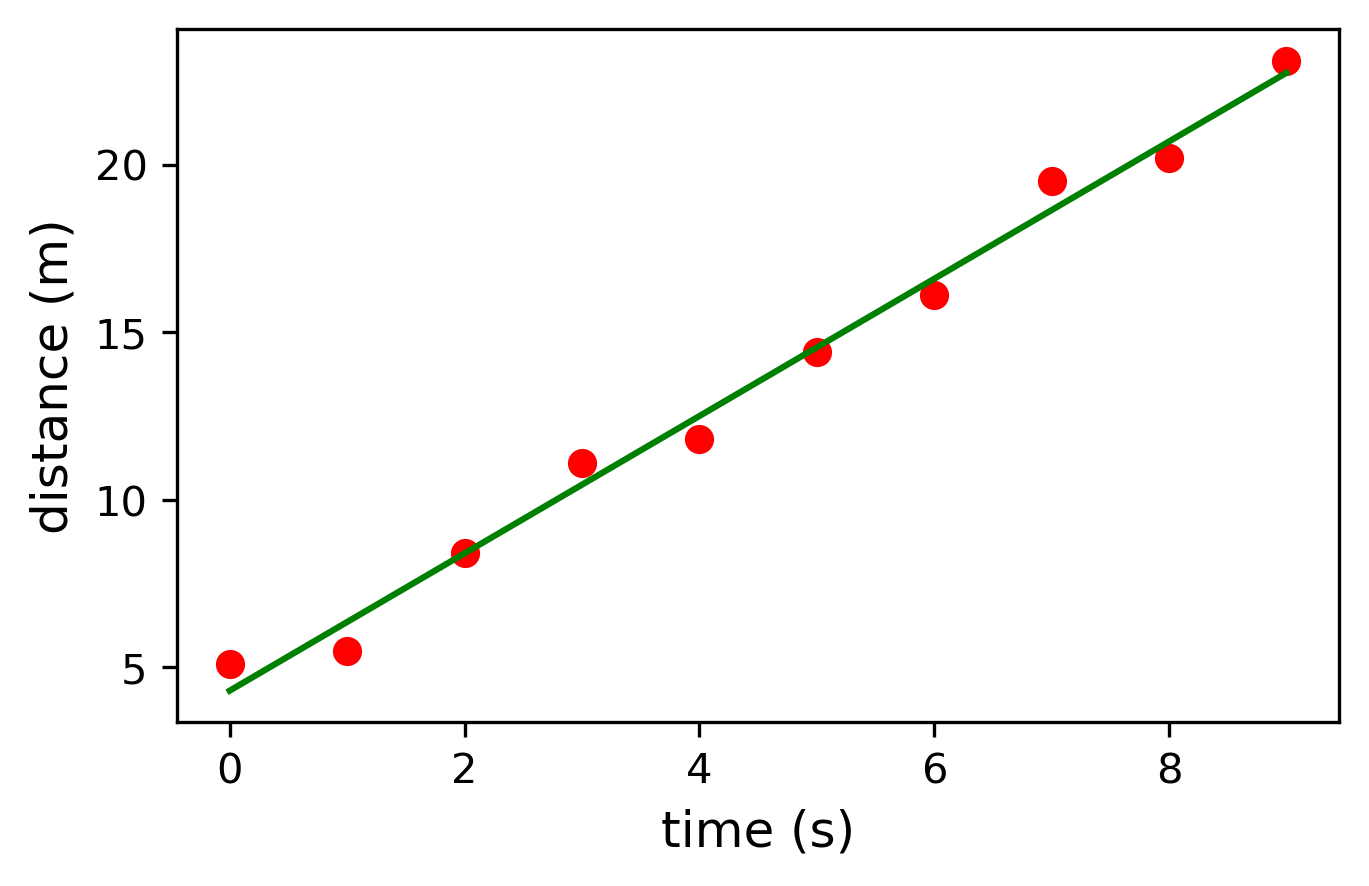

In [16]:
plt.figure(figsize=(5,3))
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'g'); #grafique la recta con los mejores parámetros

Y si agregamos incerteza en la medición de distancias?

In [17]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [18]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

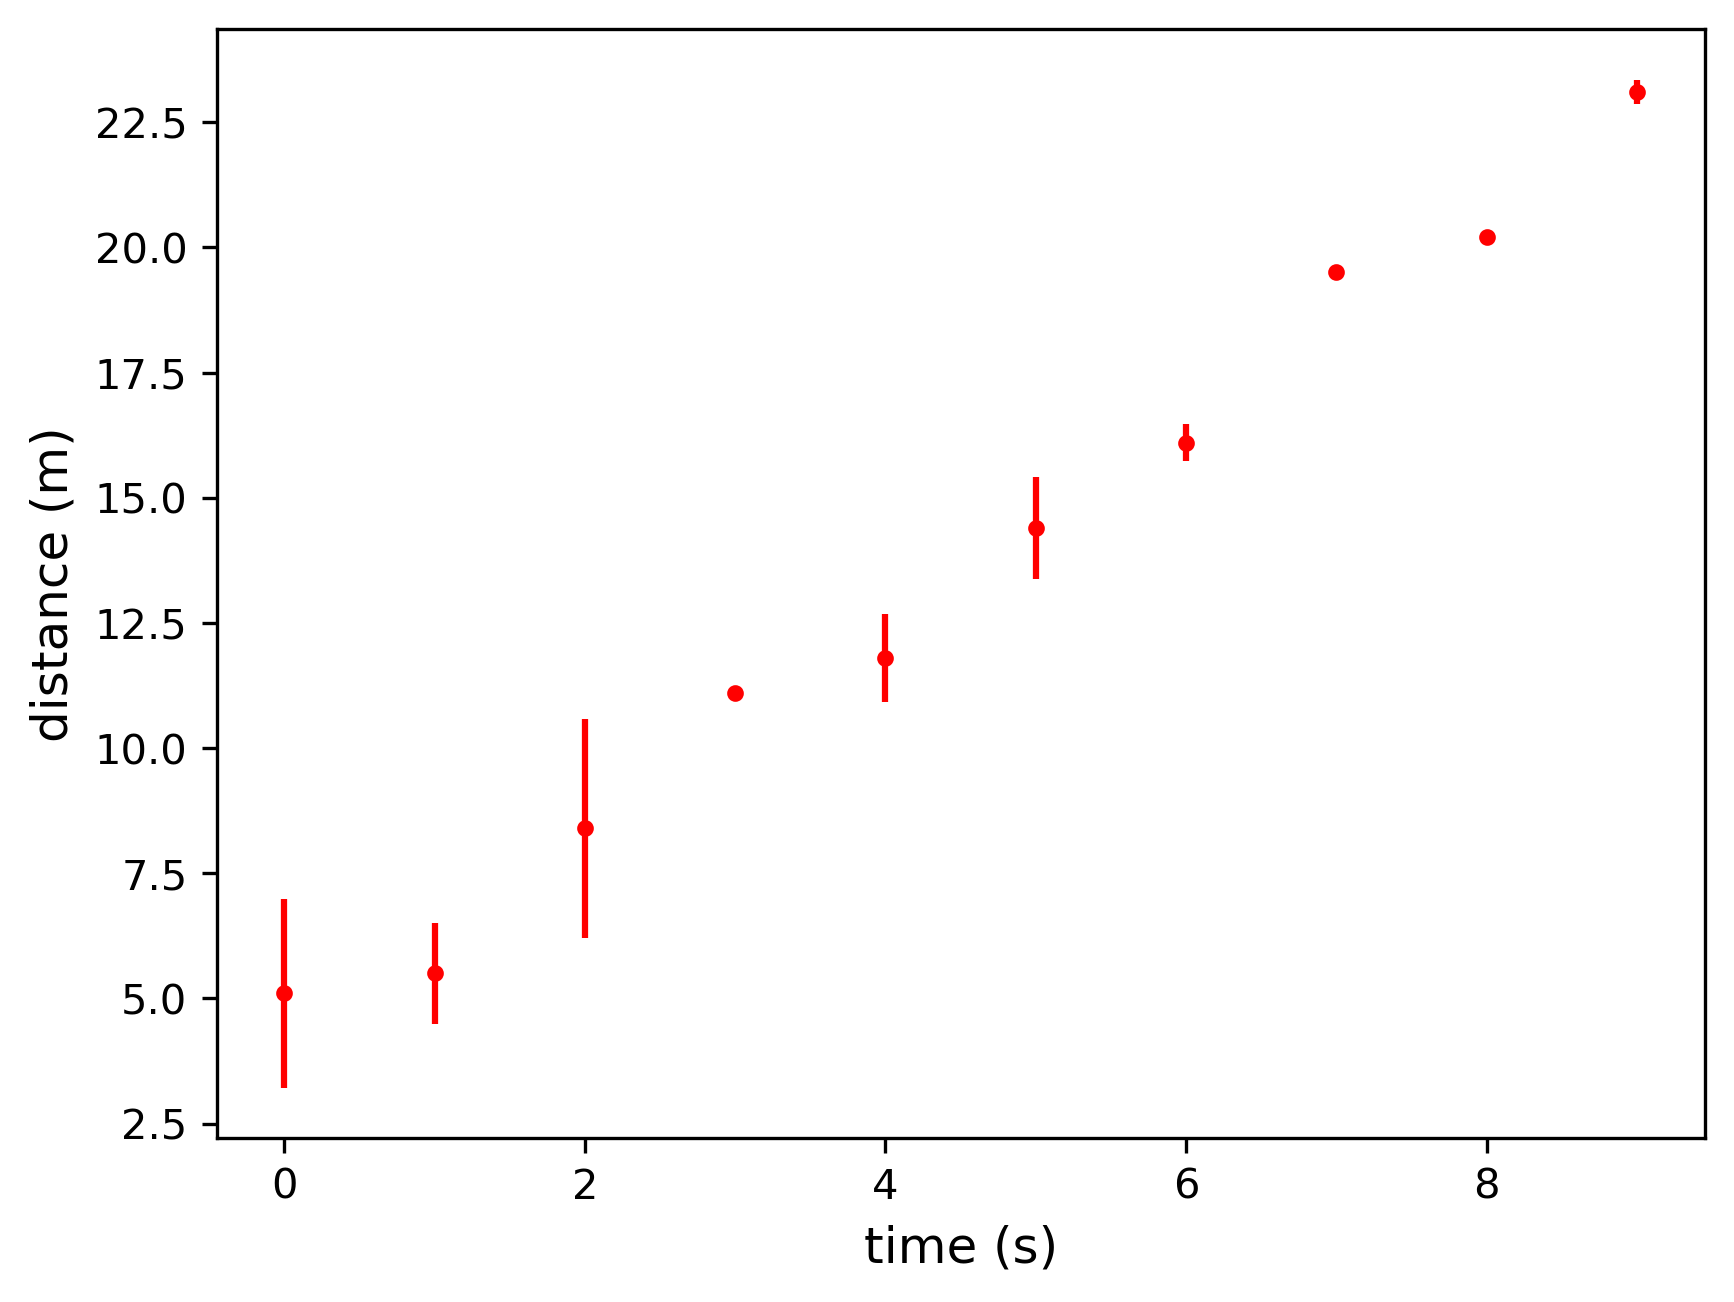

In [19]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Encuentre los parámetros de la mejor recta cuando agregamos incertezas

In [20]:
Recta2 = np.polynomial.polynomial.polyfit(x, y, 1, w=1/dy**2)
Recta2

array([5.6400089 , 1.81999922])

In [21]:
bestb_werr = Recta2[0]
bestm_werr = Recta2[1]

d_12werr = bestm_werr*12 + bestb_werr
d_12werr

np.float64(27.4799995160803)

Graficamos los datos con incertezas y el nuevo ajuste

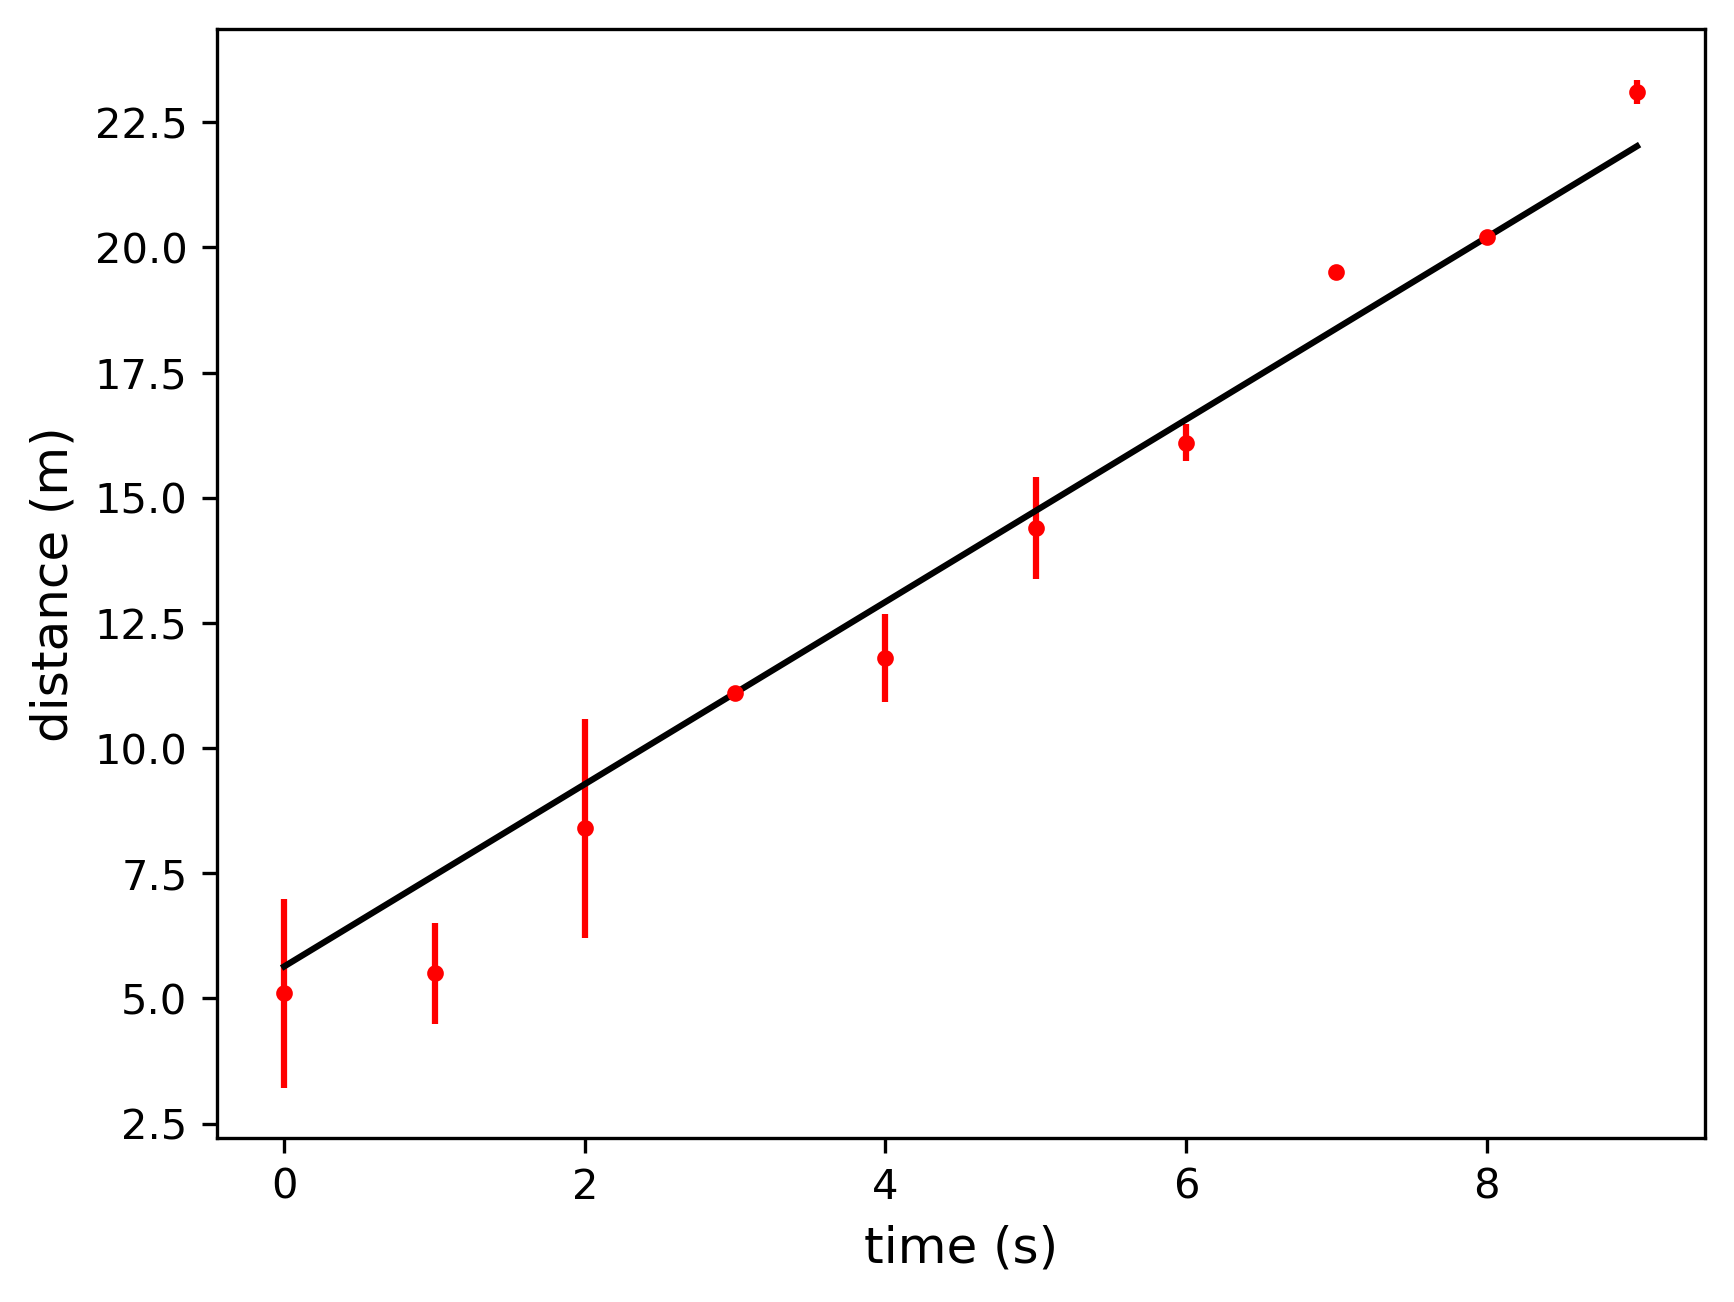

In [22]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'black') #agregue sus parámetros

In [23]:
print(f'El valor de d(t=12) en este caso es: {d_12werr:.2f} m')

El valor de d(t=12) en este caso es: 27.48 m


Comparemos ambos modelos

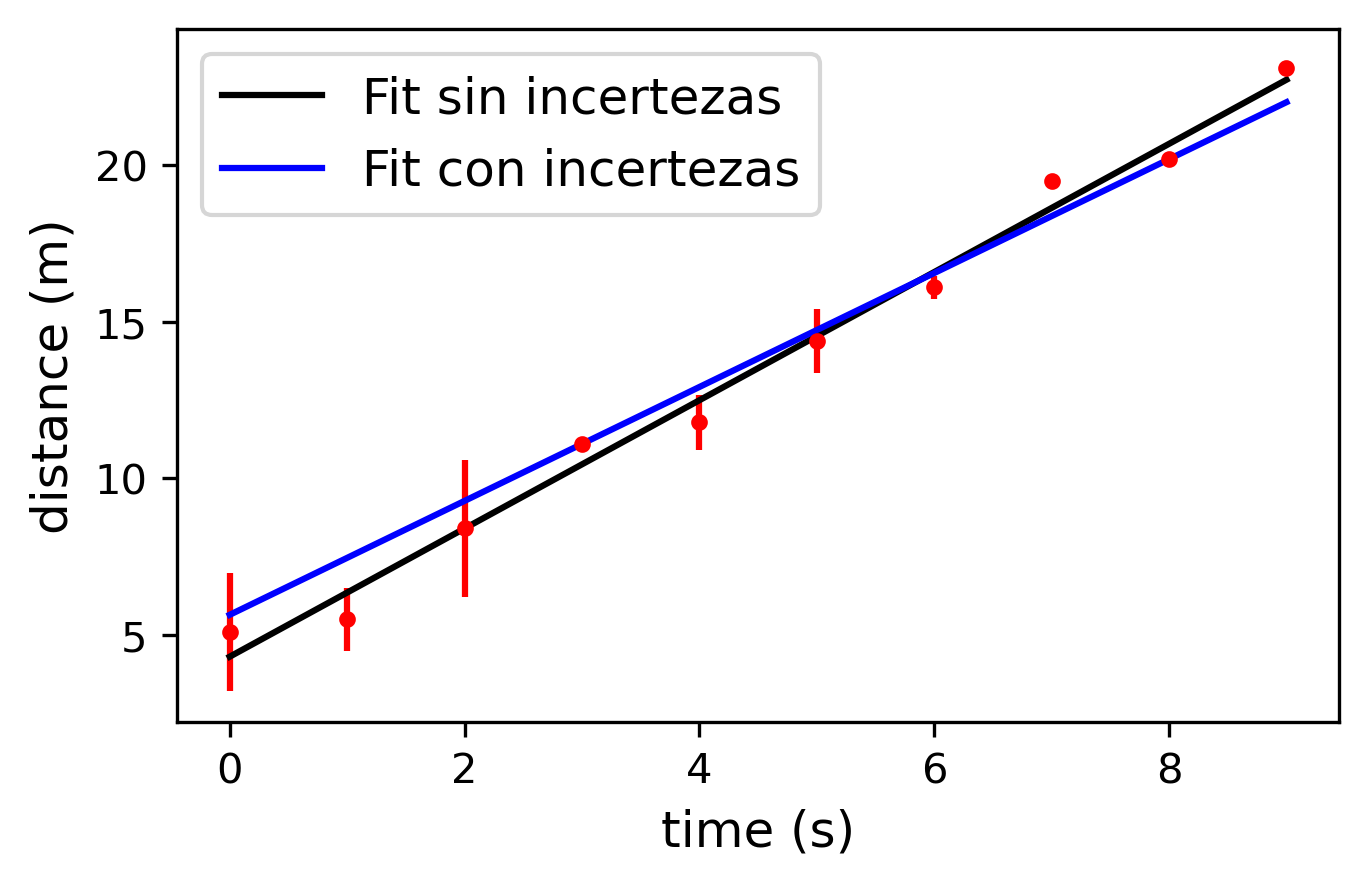

In [24]:
plt.figure(figsize=(5,3))

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')

plt.plot(x, bestb + bestm * x, c = 'black', label = 'Fit sin incertezas')

plt.plot(x, bestb_werr + bestm_werr * x, c = 'b', label = 'Fit con incertezas')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend()


*En este problema el feature es el tiempo, mientras que el target es la distancia.*

**Pregunta: ¿Tiene sentido ese cambio?**

**Si tiene sentido el cambio, pues al agregarle error a algunos de los datos, disminuye la "confianza" que podemos tener en ellos. Por esto, en el ajuste de curva con incertezas la recta prioriza ajustarse más a los datos con menor margen de error, que a aquellos con un alto margen de error. De esta manera, se toma una decisión basada principalmente en calidad de los datos, pues si no se expresara un error para cada uno de ellos, al momento de ajustar considerariamos datos buenos y malos en un mismo conjunto (que es lo que se hizo en el primer caso).**

### Parte 2: Machine Learning

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

#### Importamos de la librería Sci-kit learn los modelos ya implementados y usaremos funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook

In [25]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión

In [26]:
from sklearn.linear_model import LinearRegression #modelo de regresión lineal

In [27]:
from sklearn.model_selection import train_test_split  #para dividir los datos

In [28]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

In [29]:
np.random.seed(10) #semilla fija para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #crea los sets de entrenamiento/prueba.
#test_size determina cuantos datos se reservan para test, y deja el resto para train. En este caso son 3 datos en test y 7 en train.
#Adicionalmente un valor del tipo float=0.3 representaría un 30% de datos reservados para test y un 70% para train.

In [30]:
X_train, y_train #7 datos de entrenamiento

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [31]:
X_test, y_test # 3 de prueba

(array([8, 2, 5]), array([20.2,  8.4, 14.4]))

In [32]:
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params

In [33]:
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params default params

construimos el modelo con los datos de entrenamiento y los usamos para predecir el output en los datos de prueba

In [34]:
#predicciones de datos usando árbol de decisión
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [35]:
#predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

- .fit entrena el modelo utilizando X_train e y_train. Este entrega inmediatamente un modelo entrenado.

- .predict usa este modelo entrenado para generar predicciones sobre X_test.

- scikit-learn espera una matriz 2D, por lo que se utiliza reshape para convertir la variable unidimensional en la matriz. reshape(n_muestras, n_features), donde 1 indica que solo estamos integrando 1 feature y el -1 le dice a numpy que calcule el tamaño de la matriz automaticamente según los datos.

In [36]:
print(y_test, y_pred_reg, y_pred_tree) #Real/predicho por RL y AD respectivamente

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Ojo, ambos modelos de aprendizaje funcionan de maneras distintas, por eso entregan valores distintos.

- Regresión Lineal funciona de manera similar a como se ajusto la curva anteriormente. Minimiza la suma de errores cuadráticos y evalua la recta ajustada. Esto funciona para rectas continuas y suaves.

- El Árbol de Decisión construye un árbol dividiendo recursivamente el espacio de X_train en regiones, y busca los cortes que minimicen la varianza de y dentro de cada región. guddamit i hate trees. En X_test recorre el árbol hasta llegar a una hoja y predice el promedio de los valores de y_train que cayeron en esa región durante el entrenamiento. Su resultado no es una línea continua como en el modelo de regresión lineal, sino que produce predicciones discretas con valores concretas por región.

Usaremos como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo. Esto para evaluar cual de los dos métodos 
resultó más eficaz.

In [37]:
np.mean((y_test-y_pred_reg)**2)

np.float64(0.18201586721857252)

In [38]:
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

In [56]:
coefs = np.polynomial.polynomial.polyfit(X_train, y_train, deg=1)
y_pred_inferencia = np.polynomial.polynomial.polyval(X_test, coefs)

np.mean((y_test-y_pred_inferencia)**2)

np.float64(0.18201586721858032)

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

**El modelo que entregue el MSE más bajo será el que haya modelado mejor los datos, pues es el que minimiza las pérdidas entre los valores actuales entregados y los predichos por la curva. En este caso sería el modelo de regresión lineal. Sin embargo, esto depende netamente de los datos que tenemos, su forma, cantidad, outliers, entre otros factores.**

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [53]:
d12_treemodel = treemodel.predict(np.array(12).reshape(-1, 1))
d12_reglin = regmodel.predict(np.array(12).reshape(-1, 1))

print(f'Valor de d(t=12) en modelo de árbol de decisión: {d12_treemodel[0]}')
print(f'Valor de d(t=12) en modelo de regresión lineal: {d12_reglin[0]:.1f}')

Valor de d(t=12) en modelo de árbol de decisión: 23.1
Valor de d(t=12) en modelo de regresión lineal: 29.2


Recordemos que en los ajustes realizados en un inicio los valores obtenidos rondaron entre los 27 y 29 m.

### Conclusión

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?

**En este caso la inferencia estadística y el modelo de regresión lineal nos otorgaron valores de MSE muy similares (con diferencias por sobre el decimocuarto decimal), mientras que el modelo de árbol de decisión resultó con un MSE bastante más alto. Por esta razón, tanto la inferencia estadística como el modelo de regresión lineal funcionaron bastante bien en este problema, pero debemos de mencionar que la inferencia nos permite también hacer deducciones sobre los errores asociados a cada parámetro. Sin embargo, este era un problema simple de modelar, pero en casos más complejos ML puede realizar un mejor análisis, en especial cuando no estamos seguros del comportamiento de los datos. Por ende, para poder obtener un buen resultado con la inferencia estadística debemos de tener claridad con la forma de la curva y los parámetros de los que depende.**

- En el caso de ML, cómo elegimos el mejor modelo?

**En si, existen varios modelos para tratar de resolver un problema, por lo que la forma de decidir cuál utilizar dependerá de las características del problema, los datos que tenemos, y de como sabemos que se comporta el modelo para obtener. Pero en el final, el modelo que mejor resuelve un problema es aquel que tiene un menor MSE.**

**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.